# Skewed and heteroscedastic targets

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/biprateep/lazy-tfm/blob/tutorials/skewed_targets.ipynb)
[![View on GitHub](https://img.shields.io/badge/View%20on-GitHub-181717?logo=github)](https://github.com/biprateep/lazy-tfm/blob/tutorials/skewed_targets.ipynb)

Many targets are positive, have a long tail toward large values (i.e., are
skewed), and are more uncertain the larger they are (i.e., are
heteroscedastic), such as prices, masses, incomes and counts. In this
tutorial, we predict the prices of diamonds, which have all three properties.
We show how the predicted intervals widen with the size of a diamond, compare
a model fitted on the price with one fitted on its logarithm, and show how
the choice of output grid affects the densities.

## Setup

On Google Colab, the cell below installs the package with the TabPFN backend.
Elsewhere, install it first with `pip install 'lazy-tfm[tabpfn]'`.

In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install -q 'lazy-tfm[tabpfn]'
    pass

In [2]:
import matplotlib.pyplot as plt  # Plotting
import numpy as np  # Arrays
import pandas as pd  # Tables

import lazy
from lazy import datasets
from lazy import metrics
from lazy import plotting

SEED = 299792458  # One seed for everything random

plotting.use_style()
plt.rcParams["figure.dpi"] = 110  # Readable in a notebook

## The data

`load_dataset("diamonds")` gives the prices, in US dollars (USD), of 53,940
round-cut diamonds, with their weight (carat), their dimensions and three
quality grades: the cut, the color and the clarity (see
[Demo datasets](https://lazy-tfm.readthedocs.io/en/latest/guide/datasets.html)).
The grades are ordered categories, from worst to best. Since every model
treats every column as a number, we replace each grade by its code in that
order (see
[Limits and pitfalls](https://lazy-tfm.readthedocs.io/en/latest/guide/limits.html)).

In [3]:
data = datasets.load_dataset("diamonds")
X = data.X.copy()
for column in ("cut", "color", "clarity"):
    X[column] = X[column].cat.codes
price = data.y

print(f"Price from {price.min():,.0f} to {price.max():,.0f} USD")
print(f"Median {np.median(price):,.0f} USD, mean {price.mean():,.0f} USD")
X.head()

Price from 326 to 18,823 USD
Median 2,401 USD, mean 3,933 USD


,carat,cut,color,clarity,depth,table,x,y,z
0,0.24,4,3,6,62.1,56.0,3.97,4.00,2.47
1,0.58,2,4,5,60.0,57.0,5.44,5.42,3.26
2,0.40,4,5,5,62.1,55.0,4.76,4.74,2.95
3,0.43,3,5,5,60.8,57.0,4.92,4.89,2.98
4,1.55,4,5,1,62.3,55.0,7.44,7.37,4.61


The mean price is well above the median, which is a sign of a long tail
toward expensive diamonds. To keep the tutorial quick, we use a random 5,000
diamonds as the context and another 2,000 as the test set. The full dataset
is well within the context limit of TabPFN-3.5 (see
[Scaling and performance](https://lazy-tfm.readthedocs.io/en/latest/guide/scaling.html)),
at the cost of a longer run.

In [4]:
rng = np.random.default_rng(SEED)
rows = rng.permutation(len(X))
train, test = rows[:5_000], rows[5_000:7_000]
X_train, X_test = X.iloc[train], X.iloc[test]
y_train, y_test = price[train], price[test]
carat = X_test["carat"].to_numpy()

## Intervals that grow with the price

We fit TabPFN-3.5 on the price itself and ask for the median and the 68%
central interval of each test diamond. Both come from the model's own
distribution and do not depend on any grid (see
[From model output to distribution](https://lazy-tfm.readthedocs.io/en/latest/guide/distributions.html)).

In [5]:
model = lazy.LazyModel(random_state=SEED)
model.fit(X_train, y_train)

q_lin = model.predict_quantiles(X_test, [0.16, 0.5, 0.84])

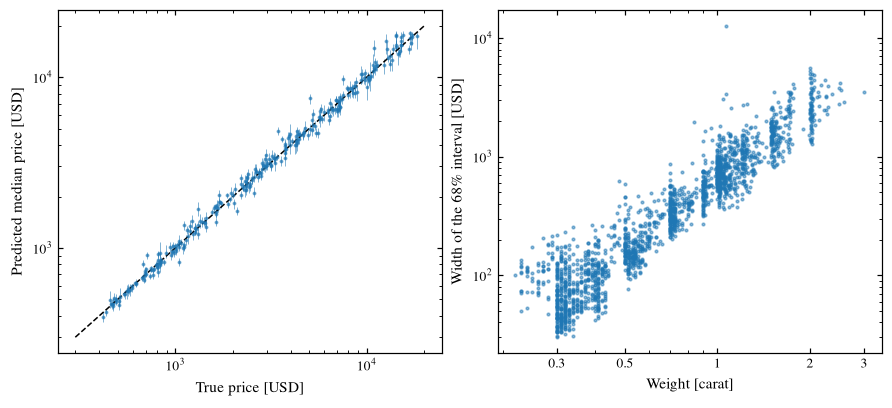

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3.6), layout="constrained")
show = rng.choice(len(test), size=300, replace=False)
ax1.errorbar(
    y_test[show],
    q_lin[show, 1],
    yerr=[q_lin[show, 1] - q_lin[show, 0], q_lin[show, 2] - q_lin[show, 1]],
    fmt=".",
    ms=3,
    lw=0.6,
    alpha=0.6,
)
ax1.plot([300, 2e4], [300, 2e4], "k--", lw=1)
ax1.set(
    xscale="log",
    yscale="log",
    xlabel="True price [USD]",
    ylabel="Predicted median price [USD]",
)
ax2.scatter(carat, q_lin[:, 2] - q_lin[:, 0], s=3, alpha=0.5)
ax2.set(
    xscale="log",
    yscale="log",
    xlabel="Weight [carat]",
    ylabel="Width of the 68% interval [USD]",
)
ax2.set_xticks([0.3, 0.5, 1, 2, 3], labels=["0.3", "0.5", "1", "2", "3"])
ax2.tick_params(axis="x", which="minor", labelbottom=False)
plt.show()

The left panel shows the predicted median and the 68% interval of 300
random test diamonds against their true price, on logarithmic axes, and the
right panel shows the width of the 68% interval of every test diamond
against its weight. We see that the medians follow the true prices over
almost two orders of magnitude, and that the intervals look of similar size
on the logarithmic axes, which means that their width in dollars grows
with the price. The width grows by about two orders of magnitude, from tens
of dollars for the lightest diamonds to thousands for the heaviest.
Therefore, a single error bar for all diamonds would be far too wide for the
cheap ones and far too narrow for the expensive ones, while the model gives
each diamond an interval of its own.

## Fitting the logarithm of the price

A common way to handle such a target is to fit its logarithm, $\ell = \ln
y$, whose spread depends much less on its size. We fit a second model on
$\ell$ and transform its answer back to prices. Since the logarithm is
monotonic, quantiles transform directly, $y_q = \exp(\ell_q)$, and so does
the 68% interval.

In [7]:
model_log = lazy.LazyModel(random_state=SEED)
model_log.fit(X_train, np.log(y_train))

q_log = np.exp(model_log.predict_quantiles(X_test, [0.16, 0.5, 0.84]))

Densities do not transform as directly as quantiles. A density in $\ell$
becomes a density in $y$ through the change of variables:

$$p_Y(y) = p_\ell(\ln y)\,\left|\frac{d\ell}{dy}\right| =
\frac{p_\ell(\ln y)}{y},$$

where $p_\ell$ is the density that the model predicts for $\ell$ and $1/y$ is
the Jacobian of the logarithm. This means that the density in $y$ is not
$p_\ell$ read at $\ln y$, and that its peak sits at a lower price than $\exp$
of the peak in $\ell$.

On a binned grid, we avoid the Jacobian, since the probability in a bin does
not depend on the variable it is measured in. The probability that the price
falls between two edges $a$ and $b$ is the probability that $\ell$ falls
between $\ln a$ and $\ln b$. We therefore build a grid in price with
logarithmically spaced edges and ask the log model for its densities on the
logarithms of the same edges. Both grids use the `"histogram"` normalization,
in which the density is constant across each bin, so the mass in a bin is the
density times the width, and the density in price is that mass divided by the
width of the bin in dollars. Since the model integrates its distribution over
each bin exactly, the transformation is exact.

In [8]:
edges = np.geomspace(100.0, 40_000.0, 301)  # USD, covers every price
price_grid = lazy.Grid.from_edges(edges, normalization="histogram")
log_grid = lazy.Grid.from_edges(np.log(edges), normalization="histogram")

pdf_lin = model.predict_proba(X_test, price_grid)
mass = model_log.predict_proba(X_test, log_grid) * log_grid.widths
pdf_log = mass / price_grid.widths

print(f"{price_grid.n_bins} bins from {edges[0]:,.0f} to {edges[-1]:,.0f} USD")
print("Probability on the grid:", (pdf_log * price_grid.widths).sum(1)[:3])

300 bins from 100 to 40,000 USD
Probability on the grid: [1. 1. 1.]


Both sets of densities are now on the same grid in dollars, so we can score
them with the same metrics (see
[From model output to distribution](https://lazy-tfm.readthedocs.io/en/latest/guide/distributions.html)).
The table lists the CRPS (in dollars), the negative log likelihood, the CDE
loss and the Kolmogorov-Smirnov statistic of the PIT, together with the
fraction of test prices inside the 68% intervals. Lower is better for all
but the last, which should be 0.68.

In [9]:
def coverage(q: np.ndarray, y: np.ndarray) -> float:
    """Fraction of the values y inside the intervals [q[:, 0], q[:, 2]]."""
    return np.mean((q[:, 0] <= y) & (y <= q[:, 2]))


table = pd.concat(
    [
        metrics.summarize(y_test, price_grid, pdf_lin, label="fit on price"),
        metrics.summarize(y_test, price_grid, pdf_log, label="fit on log"),
    ]
).set_index("model")
table["coverage_68"] = [coverage(q, y_test) for q in (q_lin, q_log)]
table[["crps", "nll", "cde_loss", "pit_ks", "coverage_68"]].round(4)

,crps,nll,cde_loss,pit_ks,coverage_68
model,,,,,
fit on price,190.674,6.6123,-0.0037,0.0254,0.695
fit on log,191.161,6.5903,-0.0042,0.0280,0.699


We see that the two models score almost the same. The model fitted on the
price has a CRPS lower by 0.5 USD (190.7 USD vs. 191.2 USD), while the model
fitted on the logarithm has a slightly lower negative log likelihood (6.590
vs. 6.612) and CDE loss (-0.0042 vs. -0.0037). Both are well calibrated,
with 69.5% and 69.9% of the test prices inside their 68% intervals.
Therefore, for TabPFN on this dataset, the logarithm does not seem to be
needed. This might be because the buckets of
its bar distribution are placed according to the targets of the context, so
that the model can already represent a skewed distribution and a spread
that grows with the target.

A coverage averaged over all diamonds can hide a miscalibration that
depends on the size of a diamond. We therefore also compute the coverage of
the 68% intervals in four bins of weight, along with the median width of
the intervals of the price model relative to its median price.

In [10]:
size = pd.cut(carat, [0, 0.5, 1.0, 1.5, 6.0])
by_size = pd.DataFrame(
    [
        {
            "n": m.sum(),
            "relative width": np.median(
                (q_lin[m, 2] - q_lin[m, 0]) / q_lin[m, 1]
            ),
            "coverage, fit on price": coverage(q_lin[m], y_test[m]),
            "coverage, fit on log": coverage(q_log[m], y_test[m]),
        }
        for m in (size == b for b in size.categories)
    ],
    index=pd.Index(size.categories.astype(str), name="weight [carat]"),
)
by_size.round(3)

,n,relative width,"coverage, fit on price","coverage, fit on log"
weight [carat],,,,
"(0.0, 0.5]",690,0.104,0.730,0.717
"(0.5, 1.0]",629,0.129,0.676,0.688
"(1.0, 1.5]",458,0.133,0.670,0.672
"(1.5, 6.0]",223,0.152,0.691,0.726


The table shows the number of test diamonds in each bin of weight, the
median ratio of the width of the 68% interval to the median price, and the
coverage of each model. The relative width grows from 10.4% for the
lightest diamonds to 15.2% for the heaviest, so the width in dollars grows
somewhat faster than the price itself. The coverage stays between 67.0% and
73.0% in every bin for both models. With 223 to 690 diamonds per bin, the
statistical uncertainty of each coverage is about 2 to 3 percentage points,
so the bins are broadly consistent with 68%, the largest departure being the
73.0% of the lightest diamonds covered by the model fitted on the price.

## The output grid

Without a grid, `predict_proba` answers on the native grid of the model,
which for TabPFN is its 5,000 buckets. These reach far into both tails,
including negative prices, because the buckets of the model lie there. The
native grid loses no information, but a grid of our own is easier to plot,
store and compare between models.

In [11]:
native = model.native_grid_
print(
    f"Native grid: {native.n_bins:,} bins from {native.edges[0]:,.0f}"
    f" to {native.edges[-1]:,.0f} USD"
)
dist = model.predict_distribution(X_test)
below_zero = dist.cdf([0.0])[:, 0]
print(f"Mean probability of a negative price: {below_zero.mean():.1e}")

Native grid: 5,000 bins from -514,955 to 523,031 USD


Mean probability of a negative price: 9.0e-05


The native grid of the model fitted on the price spans about
$\pm 5 \times 10^5$ USD, although no diamond costs less than 326 USD, and the
model puts a mean probability of $9.0 \times 10^{-5}$ on negative prices.
This is small here but not zero, and it can matter for a target closer to
zero. The model fitted on the logarithm cannot predict a negative price.

Probability outside a grid of our own is dropped and each density is
renormalized over the grid (see
[Limits and pitfalls](https://lazy-tfm.readthedocs.io/en/latest/guide/limits.html)).
To show what this does, we ask for densities on a linear grid that stops at
5,000 USD, and compare them with those on the native grid for the test
diamond whose price is closest to 6,000 USD.

True price 6,000 USD, probability below 5,000 USD: 8.0%


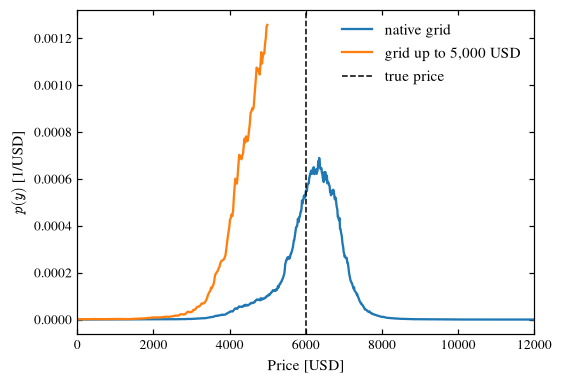

In [12]:
short_grid = lazy.Grid.linear(0.0, 5_000.0, 250)
i = int(np.argmin(np.abs(y_test - 6_000)))
one = X_test.iloc[[i]]

below = dist[i : i + 1].cdf([5_000.0])[0, 0]
print(
    f"True price {y_test[i]:,.0f} USD, probability below 5,000 USD: {below:.1%}"
)

fig, ax = plt.subplots(figsize=(5, 3.4), layout="constrained")
ax.plot(native.centers, model.predict_proba(one)[0], label="native grid")
ax.plot(
    short_grid.centers,
    model.predict_proba(one, short_grid)[0],
    label="grid up to 5,000 USD",
)
ax.axvline(y_test[i], color="k", ls="--", lw=1, label="true price")
ax.set(xlim=(0, 12_000), xlabel="Price [USD]", ylabel="$p(y)$ [1/USD]")
ax.legend()
plt.show()

The figure shows the density of this diamond on the native grid and on the
grid that stops at 5,000 USD, along with its true price (about
6,000 USD). On the native grid, the density peaks close to the true price. The
short grid holds only 8.0% of the probability of this diamond, and since that
8.0% is renormalized to one, the density piles up against the end of the grid,
with its peak at 5,000 USD and almost twice as high as the peak on the native
grid. Therefore, a grid must cover the targets, and the log-spaced grid we
used above, from 100 to 40,000 USD, covers every price in the dataset.

For the next steps, we suggest the following pages:

- [From model output to distribution](https://lazy-tfm.readthedocs.io/en/latest/guide/distributions.html):
  native grids, user grids and their normalizations.
- [Limits and pitfalls](https://lazy-tfm.readthedocs.io/en/latest/guide/limits.html):
  probability outside the grid, and categorical columns.